# Sprint 4 — v8: retrain without the source embedding

**Project:** Q-INTERVAL-Lite+ · **Author:** Pasindu Pahasara (104348348)

## Why

The step-1 audit found the model had learned source-conditional class priors:

| Source | Normal | Malignant | Model's malignant recall |
|---|---|---|---|
| CMMD | 0.0% | 78.7% | 0.9514 |
| KAU-BCMD | 83.7% | 4.3% | **0.1429** |
| DDSM | 26.7% | 35.2% | 0.6168 |

Source identity alone — no image — reaches macro AUC 0.7346. Per-source accuracy tracks the
per-source class prior, and on KAU-BCMD, the one source resembling a screening population,
the model catches 14% of cancers while scoring 96% accuracy by predicting Normal.

Source dataset is an artifact of how Mammo-Bench was assembled. It does not exist at
inference time on a real patient. It should never have been an input.

## What changes

- **Source embedding removed.** Age, view and laterality stay — they are legitimate clinical
  covariates available at inference.
- **Frozen split used.** Training on the new train pool plus the old validation set; model
  selection on the fresh selection set; the 831-patient test set stays untouched.
- **Per-source metrics logged every epoch**, including worst-source malignant recall, so the
  failure mode is visible during training rather than discovered afterwards.
- **Checkpoint selection can optimise worst-source performance** rather than the aggregate.

Expect the headline number to drop. That is the point — the previous number was partly
measuring provenance.

## 1. Configuration

In [ ]:
# ---------------- CONFIG ----------------
ARCH        = 'effnetv2'    # 'effnetv2' (v6 recipe, 384px) | 'resnet101' (v5 recipe, 512px)
                            # ResNet-101 run is already complete - this is the matched pair
USE_SOURCE  = False         # the whole point of this notebook
LOSS_TYPE   = 'ce'          # 'ce' | 'focal' | 'lmf'
USE_SAMPLER = True

# Checkpoint selection.
#   macro_f1              - aggregate, the conventional choice
#   worst_src_mal_recall  - optimises the failure mode the audit found
#   balanced              - 0.5 * macro_f1 + 0.5 * worst-source malignant recall
SELECT_ON   = 'balanced'
MIN_MAL_FOR_SELECTION = 20  # a source needs this many malignant cases in the
                            # selection set before it can drive checkpoint choice

EPOCHS   = 25
PATIENCE = 6
LR       = 1e-4
WD       = 1e-4

FOCAL_GAMMA = 2.0
LDAM_MAX_M, LDAM_S = 0.5, 30
LMF_ALPHA, LMF_BETA = 1.0, 1.0
DRW_START_EPOCH = None
# ----------------------------------------

TAG = f"v8_{ARCH}_{'src' if USE_SOURCE else 'nosrc'}_{LOSS_TYPE}"
print('Experiment:', TAG)
print('Selection criterion:', SELECT_ON)

Experiment: v8_effnetv2_nosrc_ce
Selection criterion: balanced


## 2. Setup

In [ ]:
!pip install -q albumentations scikit-learn tqdm matplotlib seaborn

import os, time, json, random
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import (resnet101, ResNet101_Weights,
                                efficientnet_v2_s, EfficientNet_V2_S_Weights)
import cv2, albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix, classification_report)
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
CLASS_NAMES = ['Normal', 'Benign', 'Malignant']
MAL = 2
print('Device:', device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = '/content/drive/MyDrive/momobench-dataset'
EXTRACT_DIR = '/content/dataset_original'
CHECKPT_DIR = os.path.join(DRIVE_ROOT, f'checkpoints_{TAG}')
SPLIT_PATH  = os.path.join(DRIVE_ROOT, 'sprint4_audit', 'frozen_split.json')
os.makedirs(CHECKPT_DIR, exist_ok=True)

if not os.path.isdir(os.path.join(EXTRACT_DIR, 'dataset')):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    os.system(f'unzip -q "{DRIVE_ROOT}/dataset.zip" -d "{EXTRACT_DIR}"')
    print('extracted')
else:
    print('already extracted')

IMG_ROOT  = os.path.join(EXTRACT_DIR, 'dataset')
META_PATH = os.path.join(IMG_ROOT, 'metadata.csv')
print('frozen split available:', os.path.exists(SPLIT_PATH))

Mounted at /content/drive
extracted
frozen split available: True


## 3. Data — frozen split, no source feature

Train pool is the new train set plus the old validation set. The old validation set was only
ever used for *selection*, never for training, so folding it in now is legitimate and gives
more data than the original runs had. Selection happens on the fresh holdout. Test is
untouched.

In [ ]:
df = pd.read_csv(META_PATH)
df['classification'] = df['classification'].replace({'Suspicious Malignant': 'Malignant'})
df = df[df['source_dataset'] != 'cdd-cesm'].reset_index(drop=True)
df['image_path'] = df['preprocessed_image_path'].apply(lambda r: os.path.join(IMG_ROOT, r))
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
df['label'] = df['classification'].map({c: i for i, c in enumerate(CLASS_NAMES)})

def age_bucket(a):
    if pd.isna(a): return 7
    for i, hi in enumerate([30, 40, 50, 60, 70, 80]):
        if a < hi: return i
    return 6
df['age_idx']  = df['subject_age'].apply(age_bucket); N_AGE = 8
df['view_idx'] = df['view'].map({'CC': 0, 'MLO': 1}).fillna(2).astype(int); N_VIEW = 3
df['lat_idx']  = df['laterality'].map({'L': 0, 'R': 1}).astype(int); N_LAT = 2
SOURCE_NAMES = sorted(df['source_dataset'].unique()); N_SRC = len(SOURCE_NAMES)
df['src_idx'] = df['source_dataset'].map({s: i for i, s in enumerate(SOURCE_NAMES)})

if os.path.exists(SPLIT_PATH):
    sp = json.load(open(SPLIT_PATH))
    train_ids = set(sp['train']) | set(sp['validation'])   # fold old val into training
    sel_ids   = set(sp['selection'])
    test_ids  = set(sp['test'])
    print('Using frozen split from the audit.')
else:
    raise FileNotFoundError('Run Sprint4_Step1_Audit.ipynb first to create frozen_split.json')

train_df = df[df['source_subjectID'].isin(train_ids)].reset_index(drop=True)
sel_df   = df[df['source_subjectID'].isin(sel_ids)].reset_index(drop=True)
test_df  = df[df['source_subjectID'].isin(test_ids)].reset_index(drop=True)

CLS_NUM_LIST = train_df['label'].value_counts().sort_index().to_numpy()
print(f'train     {len(train_df):5d} images  ({train_df.source_subjectID.nunique()} patients)')
print(f'selection {len(sel_df):5d} images  ({sel_df.source_subjectID.nunique()} patients)')
print(f'test      {len(test_df):5d} images  ({test_df.source_subjectID.nunique()} patients)  FROZEN')
print(f'\ntrain class counts: {dict(zip(CLASS_NAMES, CLS_NUM_LIST))}')
print(f'metadata used: age, view, laterality' + (', SOURCE' if USE_SOURCE else '   (source EXCLUDED)'))

Using frozen split from the audit.
train     13917 images  (4122 patients)
selection  1990 images  (581 patients)
test       2821 images  (831 patients)  FROZEN

train class counts: {'Normal': np.int64(3642), 'Benign': np.int64(4276), 'Malignant': np.int64(5999)}
metadata used: age, view, laterality   (source EXCLUDED)


## 4. Augmentation and loaders

In [ ]:
IMG_SIZE   = 512 if ARCH == 'resnet101' else 384
BATCH_SIZE = 16  if ARCH == 'resnet101' else 32
NORM_MEAN, NORM_STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.12, rotate_limit=18,
                       border_mode=cv2.BORDER_CONSTANT, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.18, contrast_limit=0.18, p=0.5),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()])
eval_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
                     A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()])


class MammoDS(Dataset):
    """Returns source index for reporting only - never fed to the model when USE_SOURCE is False."""
    def __init__(self, d, transform):
        self.df = d.reset_index(drop=True); self.tf = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r['image_path']), cv2.COLOR_BGR2RGB)
        return (self.tf(image=img)['image'], int(r['age_idx']), int(r['view_idx']),
                int(r['lat_idx']), int(r['src_idx']), int(r['label']))


train_ds, sel_ds, test_ds = MammoDS(train_df, train_tf), MammoDS(sel_df, eval_tf), MammoDS(test_df, eval_tf)

if USE_SAMPLER:
    w = 1.0 / CLS_NUM_LIST
    sw = train_df['label'].map(lambda c: w[c]).to_numpy()
    sampler = WeightedRandomSampler(torch.tensor(sw, dtype=torch.double), len(sw), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=2, pin_memory=True)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
sel_loader  = DataLoader(sel_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'{ARCH} @ {IMG_SIZE}px, batch {BATCH_SIZE}')

effnetv2 @ 384px, batch 32


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 5. Model — three metadata embeddings, not four

The only structural change. Combined feature dimension drops by 16.

In [ ]:
N_META = 4 if USE_SOURCE else 3      # age, view, laterality [, source]

class CBAM(nn.Module):
    def __init__(self, c, r=16, k=7):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1); self.mx = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Conv2d(c, c//r, 1, bias=False), nn.ReLU(inplace=True),
                                 nn.Conv2d(c//r, c, 1, bias=False))
        self.sp = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        x = x * torch.sigmoid(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))
        return x * torch.sigmoid(self.sp(torch.cat([x.mean(1, keepdim=True),
                                                    x.amax(1, keepdim=True)], 1)))

class MetaHead(nn.Module):
    def __init__(self, feat_dim, emb=16, nc=3, dr=0.3):
        super().__init__()
        self.age_emb  = nn.Embedding(N_AGE,  emb)
        self.view_emb = nn.Embedding(N_VIEW, emb)
        self.lat_emb  = nn.Embedding(N_LAT,  emb)
        self.src_emb  = nn.Embedding(N_SRC,  emb) if USE_SOURCE else None
        self.classifier = nn.Sequential(
            nn.Dropout(dr), nn.Linear(feat_dim + N_META*emb, 256),
            nn.ReLU(inplace=True), nn.Dropout(dr), nn.Linear(256, nc))
    def meta(self, a, v, l, s):
        parts = [self.age_emb(a), self.view_emb(v), self.lat_emb(l)]
        if self.src_emb is not None: parts.append(self.src_emb(s))
        return torch.cat(parts, 1)

class ResNet101_Meta(MetaHead):
    def __init__(self, **kw):
        super().__init__(feat_dim=2048, **kw)
        self.backbone = resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
        self.backbone.fc = nn.Identity()
    def forward(self, x, a, v, l, s):
        return self.classifier(torch.cat([self.backbone(x), self.meta(a,v,l,s)], 1))

class EffNetV2_CBAM_Meta(MetaHead):
    def __init__(self, **kw):
        super().__init__(feat_dim=1280, **kw)
        self.features = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1).features
        self.cbam = CBAM(1280); self.avgpool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x, a, v, l, s):
        f = self.avgpool(self.cbam(self.features(x))).flatten(1)
        return self.classifier(torch.cat([f, self.meta(a,v,l,s)], 1))

model = (ResNet101_Meta() if ARCH == 'resnet101' else EffNetV2_CBAM_Meta()).to(device)
print(f'{ARCH}: {sum(p.numel() for p in model.parameters())/1e6:.2f}M params')
print('source embedding present:', model.src_emb is not None)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 105MB/s]


effnetv2: 20.72M params
source embedding present: False


## 6. Losses

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__(); self.gamma=gamma; self.weight=weight
    def forward(self, x, t):
        w = self.weight.to(x.device) if self.weight is not None else None
        ce = F.cross_entropy(x, t, weight=w, reduction='none')
        return ((1-torch.exp(-ce))**self.gamma * ce).mean()

class LDAMLoss(nn.Module):
    def __init__(self, cls_num_list, max_m=0.5, s=30, weight=None):
        super().__init__()
        m = 1.0/np.sqrt(np.sqrt(np.asarray(cls_num_list, float))); m = m*(max_m/m.max())
        self.register_buffer('m_list', torch.tensor(m, dtype=torch.float32))
        self.s=s; self.weight=weight
    def forward(self, x, t):
        idx = torch.zeros_like(x, dtype=torch.bool); idx.scatter_(1, t.view(-1,1), True)
        out = torch.where(idx, x - self.m_list.to(x.device)[t].view(-1,1), x)
        w = self.weight.to(x.device) if self.weight is not None else None
        return F.cross_entropy(self.s*out, t, weight=w)

class LMFLoss(nn.Module):
    def __init__(self, cls_num_list, a=1.0, b=1.0, gamma=2.0, max_m=0.5, s=30, weight=None):
        super().__init__()
        self.f = FocalLoss(gamma, weight); self.l = LDAMLoss(cls_num_list, max_m, s, weight)
        self.a, self.b = a, b
    def forward(self, x, t): return self.a*self.f(x,t) + self.b*self.l(x,t)

def build_criterion(kind, cls, weight=None):
    if kind == 'ce':    return nn.CrossEntropyLoss(weight=weight.to(device) if weight is not None else None)
    if kind == 'focal': return FocalLoss(FOCAL_GAMMA, weight)
    if kind == 'lmf':   return LMFLoss(cls, LMF_ALPHA, LMF_BETA, FOCAL_GAMMA, LDAM_MAX_M, LDAM_S, weight)
    raise ValueError(kind)

def cb_weights(cls, beta=0.9999):
    eff = 1.0 - np.power(beta, cls); w = (1.0-beta)/eff
    return torch.tensor(w/w.sum()*len(cls), dtype=torch.float32)

criterion = build_criterion(LOSS_TYPE, CLS_NUM_LIST)
print('loss:', LOSS_TYPE)

loss: ce


## 7. Training with per-source monitoring

Every epoch reports aggregate metrics **and** malignant recall on the weakest source. The
audit found this ranged from 0.14 to 0.95 across sources while the aggregate looked healthy,
so the aggregate alone hides the failure.

In [ ]:
def train_one_epoch(m, loader, opt, crit, scaler):
    m.train(); tot, corr, n = 0.0, 0, 0
    for x, a, v, l, s, y in tqdm(loader, leave=False, desc='train'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        a,v,l,s = a.to(device), v.to(device), l.to(device), s.to(device)
        opt.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            logits = m(x,a,v,l,s); loss = crit(logits, y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tot += loss.item()*x.size(0); corr += (logits.argmax(1)==y).sum().item(); n += x.size(0)
    return tot/n, corr/n


@torch.no_grad()
def evaluate(m, loader, crit, src_arr=None):
    m.eval(); tot, n = 0.0, 0; L, Y = [], []
    for x, a, v, l, s, y in tqdm(loader, leave=False, desc='eval'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        a,v,l,s = a.to(device), v.to(device), l.to(device), s.to(device)
        with torch.amp.autocast(device_type='cuda'):
            logits = m(x,a,v,l,s); loss = crit(logits, y)
        tot += loss.item()*x.size(0); n += x.size(0)
        L.append(logits.float().cpu()); Y.append(y.cpu())
    L, Y = torch.cat(L), torch.cat(Y)
    pred, yt = L.argmax(1).numpy(), Y.numpy()
    probs = F.softmax(L, 1).numpy()
    f1s = f1_score(yt, pred, average=None, labels=[0,1,2], zero_division=0)
    out = {'loss': tot/n,
           'accuracy': accuracy_score(yt, pred),
           'macro_f1': f1_score(yt, pred, average='macro', zero_division=0),
           'benign_f1': f1s[1],
           'mal_recall': recall_score(yt, pred, labels=[MAL], average='macro', zero_division=0),
           'mcc': matthews_corrcoef(yt, pred),
           'macro_auc': roc_auc_score(yt, probs, multi_class='ovr', average='macro')}
    if src_arr is not None:
        # Report every source, but only let statistically stable ones drive
        # checkpoint selection. INbreast and DMID carry roughly 5-10 malignant
        # cases in the selection set, so their recall moves in 0.1-0.2 steps and
        # would otherwise decide which epoch is kept on near-noise.
        per_all, per_stable = {}, {}
        for si, sname in enumerate(SOURCE_NAMES):
            mk = src_arr == si
            if mk.sum() < 20: continue
            r = recall_score(yt[mk], pred[mk], labels=[MAL],
                             average='macro', zero_division=0)
            per_all[sname] = r
            if (yt[mk] == MAL).sum() >= MIN_MAL_FOR_SELECTION:
                per_stable[sname] = r
        out['per_source_mal_recall'] = per_all
        out['stable_sources']        = sorted(per_stable)
        out['worst_src_mal_recall']  = min(per_stable.values()) if per_stable else 0.0
        out['worst_src_name']        = min(per_stable, key=per_stable.get) if per_stable else '-'
    return out, L, Y, probs


sel_src  = sel_df['src_idx'].to_numpy()
test_src = test_df['src_idx'].to_numpy()

print('Malignant cases per source in the SELECTION set:')
for si, s in enumerate(SOURCE_NAMES):
    mk = sel_src == si
    n_mal = int((sel_df['label'].to_numpy()[mk] == MAL).sum())
    flag = 'drives selection' if n_mal >= MIN_MAL_FOR_SELECTION else 'reported only (too few)'
    print(f'  {s:10s} n={int(mk.sum()):4d}  malignant={n_mal:3d}   {flag}')

Malignant cases per source in the SELECTION set:
  cmmd       n= 530  malignant=414   drives selection
  ddsm       n=1116  malignant=384   drives selection
  dmid       n=  53  malignant= 15   reported only (too few)
  inbreast   n=  43  malignant= 10   reported only (too few)
  kau-bcmd   n= 248  malignant= 10   reported only (too few)


In [ ]:
scaler = torch.amp.GradScaler('cuda')
opt = AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

CKPT = os.path.join(CHECKPT_DIR, f'best_{TAG}.pth')
best, patience_ctr, history = -1.0, 0, []

def score_of(m):
    if SELECT_ON == 'macro_f1':             return m['macro_f1']
    if SELECT_ON == 'worst_src_mal_recall': return m['worst_src_mal_recall']
    if SELECT_ON == 'balanced':             return 0.5*m['macro_f1'] + 0.5*m['worst_src_mal_recall']
    raise ValueError(SELECT_ON)

for ep in range(1, EPOCHS+1):
    if DRW_START_EPOCH is not None and ep == DRW_START_EPOCH:
        criterion = build_criterion(LOSS_TYPE, CLS_NUM_LIST, cb_weights(CLS_NUM_LIST))
        print(f'--- epoch {ep}: DRW enabled ---')
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, criterion, scaler)
    sm, *_ = evaluate(model, sel_loader, criterion, sel_src)
    sched.step()

    ps = '  '.join(f'{k[:4]}={v:.2f}' for k, v in sm['per_source_mal_recall'].items())
    print(f'ep {ep:>2}: tr_acc={tr_acc:.4f} | sel_acc={sm["accuracy"]:.4f} '
          f'f1={sm["macro_f1"]:.4f} ben={sm["benign_f1"]:.4f} mal={sm["mal_recall"]:.4f} '
          f'| WORST-SRC mal_rec={sm["worst_src_mal_recall"]:.3f} ({sm["worst_src_name"]}) '
          f'({time.time()-t0:.0f}s)')
    print(f'        per-source mal recall:  {ps}')
    history.append({'epoch': ep, 'tr_acc': tr_acc,
                    **{k: v for k, v in sm.items() if k != 'per_source_mal_recall'}})

    sc = score_of(sm)
    if sc > best:
        best = sc
        torch.save({'model_state_dict': model.state_dict(), 'sel_metrics': sm, 'epoch': ep}, CKPT)
        print(f'        saved best ({SELECT_ON}={best:.4f})')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'        early stop after {PATIENCE} epochs'); break

train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep  1: tr_acc=0.6260 | sel_acc=0.6608 f1=0.6613 ben=0.5377 mal=0.6543 | WORST-SRC mal_rec=0.354 (ddsm) (415s)
        per-source mal recall:  cmmd=0.98  ddsm=0.35  dmid=0.27  inbr=0.00  kau-=0.00
        saved best (balanced=0.5077)


train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

...

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep 24: tr_acc=0.9417 | sel_acc=0.6824 f1=0.6844 ben=0.5513 mal=0.6963 | WORST-SRC mal_rec=0.568 (ddsm) (358s)
        per-source mal recall:  cmmd=0.83  ddsm=0.57  dmid=0.80  inbr=0.40  kau-=0.10


train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep 25: tr_acc=0.9425 | sel_acc=0.6884 f1=0.6911 ben=0.5611 mal=0.7071 | WORST-SRC mal_rec=0.594 (ddsm) (362s)
        per-source mal recall:  cmmd=0.83  ddsm=0.59  dmid=0.80  inbr=0.40  kau-=0.10


## 8. Training curves — watch the worst-source line

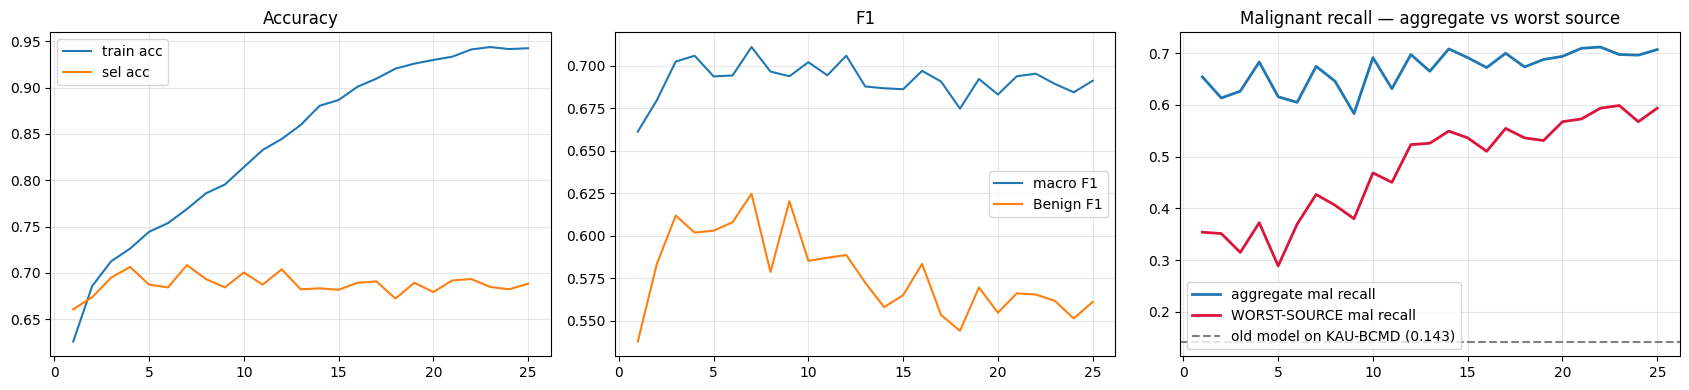

,epoch,tr_acc,loss,accuracy,macro_f1,benign_f1,mal_recall,mcc,macro_auc,stable_sources,worst_src_mal_recall,worst_src_name
13,14,0.8804,0.8676,0.6834,0.6867,0.5580,0.7083,0.5151,0.8587,"[cmmd, ddsm]",0.5495,ddsm
14,15,0.8866,0.9346,0.6819,0.6862,0.5650,0.6915,0.5136,0.8560,"[cmmd, ddsm]",0.5365,ddsm
15,16,0.9010,0.9891,0.6894,0.6970,0.5834,0.6723,0.5285,0.8609,"[cmmd, ddsm]",0.5104,ddsm
16,17,0.9098,1.0731,0.6910,0.6907,0.5533,0.6999,0.5287,0.8569,"[cmmd, ddsm]",0.5547,ddsm
17,18,0.9205,1.0947,0.6724,0.6748,0.5441,0.6735,0.5001,0.8552,"[cmmd, ddsm]",0.5365,ddsm
18,19,0.9259,1.0305,0.6894,0.6922,0.5695,0.6879,0.5268,0.8641,"[cmmd, ddsm]",0.5312,ddsm
19,20,0.9299,1.0853,0.6794,0.6831,0.5547,0.6939,0.5096,0.8571,"[cmmd, ddsm]",0.5677,ddsm
20,21,0.9334,1.1005,0.6920,0.6938,0.5661,0.7095,0.5290,0.8598,"[cmmd, ddsm]",0.5729,ddsm
21,22,0.9412,1.1508,0.6935,0.6953,0.5654,0.7119,0.5313,0.8563,"[cmmd, ddsm]",0.5938,ddsm
22,23,0.9438,1.1904,0.6849,0.6894,0.5617,0.6975,0.5181,0.8529,"[cmmd, ddsm]",0.5990,ddsm


In [ ]:
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(h.epoch, h.tr_acc, label='train acc'); ax[0].plot(h.epoch, h.accuracy, label='sel acc')
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h.epoch, h.macro_f1, label='macro F1'); ax[1].plot(h.epoch, h.benign_f1, label='Benign F1')
ax[1].set_title('F1'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(h.epoch, h.mal_recall, label='aggregate mal recall', lw=2)
ax[2].plot(h.epoch, h.worst_src_mal_recall, label='WORST-SOURCE mal recall', lw=2, color='crimson')
ax[2].axhline(0.1429, ls='--', c='grey', label='old model on KAU-BCMD (0.143)')
ax[2].set_title('Malignant recall — aggregate vs worst source'); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
display(h.round(4).tail(12))

## 9. Test evaluation with per-source breakdown

Loaded epoch 22


eval:   0%|          | 0/89 [00:00<?, ?it/s]


AGGREGATE TEST METRICS
  accuracy     = 0.7097
  macro_f1     = 0.7152
  benign_f1    = 0.5851
  mal_recall   = 0.7229
  mcc          = 0.5508
  macro_auc    = 0.8675

PER-SOURCE BREAKDOWN


,n,pct_malignant,accuracy,macro_f1,benign_f1,mal_recall
source,,,,,,
cmmd,826,0.797,0.7518,0.5999,0.3533,0.8587
ddsm,1528,0.359,0.6387,0.6488,0.6210,0.5912
dmid,76,0.276,0.6184,0.5758,0.4681,0.3810
inbreast,61,0.246,0.7705,0.7053,0.8354,0.6000
kau-bcmd,330,0.042,0.9424,0.6546,0.7857,0.1429


Worst-source malignant recall: 0.1429 (kau-bcmd)
Spread across sources:         0.7158


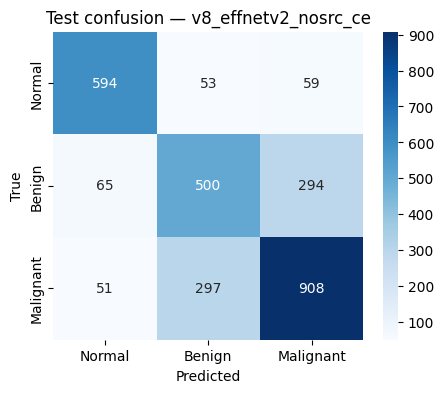

              precision    recall  f1-score   support

      Normal     0.8366    0.8414    0.8390       706
      Benign     0.5882    0.5821    0.5851       859
   Malignant     0.7201    0.7229    0.7215      1256

    accuracy                         0.7097      2821
   macro avg     0.7150    0.7155    0.7152      2821
weighted avg     0.7091    0.7097    0.7094      2821



In [ ]:
ck = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(ck['model_state_dict'])
print(f'Loaded epoch {ck["epoch"]}')

tm, test_logits, test_y, test_probs = evaluate(model, test_loader, criterion, test_src)
yt = test_y.numpy(); pred = test_logits.argmax(1).numpy()

print('\nAGGREGATE TEST METRICS')
for k in ['accuracy','macro_f1','benign_f1','mal_recall','mcc','macro_auc']:
    print(f'  {k:12s} = {tm[k]:.4f}')

rows = []
for si, s in enumerate(SOURCE_NAMES):
    mk = test_src == si
    if mk.sum() < 20: continue
    y_s, p_s = yt[mk], pred[mk]
    f1s = f1_score(y_s, p_s, average=None, labels=[0,1,2], zero_division=0)
    rows.append({'source': s, 'n': int(mk.sum()),
                 'pct_malignant': round((y_s == MAL).mean(), 3),
                 'accuracy': accuracy_score(y_s, p_s),
                 'macro_f1': f1_score(y_s, p_s, average='macro', zero_division=0),
                 'benign_f1': f1s[1],
                 'mal_recall': recall_score(y_s, p_s, labels=[MAL], average='macro', zero_division=0)})
per_src = pd.DataFrame(rows).set_index('source').round(4)
print('\nPER-SOURCE BREAKDOWN')
display(per_src)
print(f"Worst-source malignant recall: {per_src['mal_recall'].min():.4f} "
      f"({per_src['mal_recall'].idxmin()})")
print(f"Spread across sources:         {per_src['mal_recall'].max()-per_src['mal_recall'].min():.4f}")

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(yt, pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Test confusion — {TAG}')
plt.show()
print(classification_report(yt, pred, target_names=CLASS_NAMES, digits=4))

## 10. Comparison against the source-using baseline

The old ensemble scored 0.7373 aggregate but ranged from 0.14 to 0.95 malignant recall
across sources. A lower aggregate with a much tighter spread is the better model.

NOTE: OLD is a 2-model ensemble with TTA and threshold tuning; the rows below
are single models without either. The fair comparison comes after ensembling
this model with v8 ResNet-101 in the Tier 1 notebook.



,S3 ensemble (source),v8 ResNet (no source),v8 effnetv2 (no source)
metric,,,
accuracy,0.7373,0.6930,0.7097
macro_f1,0.7415,0.7033,0.7152
benign_f1,0.6340,0.5942,0.5851
mal_recall,0.7811,0.6728,0.7229
mcc,0.5908,0.5286,0.5508
macro_auc,0.8918,0.8696,0.8675
WORST-SOURCE mal recall,0.1429,0.4000,0.1429
source spread (lower better),0.8085,0.3660,0.7158


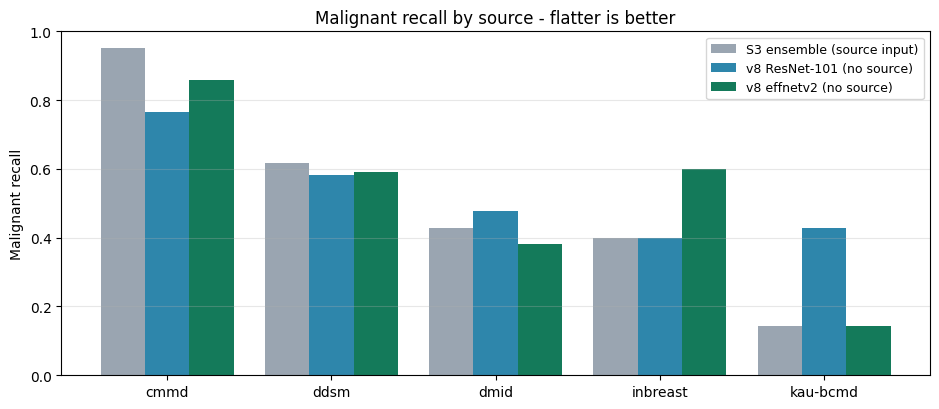

KAU-BCMD is the screening-like source: 84% normal, 4% malignant.
It is the closest thing in Mammo-Bench to what RSNA and a real clinic look like.


In [ ]:
# Sprint 3 ensemble WITH the source input (2 models + 4-view TTA + tuned coefficients)
OLD = {'aggregate': {'accuracy': 0.7373, 'macro_f1': 0.7415, 'benign_f1': 0.6340,
                     'mal_recall': 0.7811, 'mcc': 0.5908, 'macro_auc': 0.8918},
       'per_source_mal_recall': {'cmmd': 0.9514, 'ddsm': 0.6168, 'dmid': 0.4286,
                                 'inbreast': 0.4000, 'kau-bcmd': 0.1429}}

# v8 ResNet-101 without source - single model, no TTA, no tuning
V8_RESNET = {'aggregate': {'accuracy': 0.6930, 'macro_f1': 0.7033, 'benign_f1': 0.5942,
                           'mal_recall': 0.6728, 'mcc': 0.5286, 'macro_auc': 0.8696},
             'per_source_mal_recall': {'cmmd': 0.7660, 'ddsm': 0.5821, 'dmid': 0.4762,
                                       'inbreast': 0.4000, 'kau-bcmd': 0.4286}}

print('NOTE: OLD is a 2-model ensemble with TTA and threshold tuning; the rows below')
print('are single models without either. The fair comparison comes after ensembling')
print('this model with v8 ResNet-101 in the Tier 1 notebook.\n')

def worst_and_spread(d):
    v = list(d.values()); return min(v), max(v) - min(v)

old_worst, old_spread = worst_and_spread(OLD['per_source_mal_recall'])
rn_worst,  rn_spread  = worst_and_spread(V8_RESNET['per_source_mal_recall'])
new_worst = per_src['mal_recall'].min()
new_spread = per_src['mal_recall'].max() - new_worst

cmp_rows = [{'metric': k,
             'S3 ensemble (source)': OLD['aggregate'][k],
             'v8 ResNet (no source)': V8_RESNET['aggregate'][k],
             f'v8 {ARCH} (no source)': tm[k]} for k in OLD['aggregate']]
cmp_rows.append({'metric': 'WORST-SOURCE mal recall',
                 'S3 ensemble (source)': old_worst,
                 'v8 ResNet (no source)': rn_worst,
                 f'v8 {ARCH} (no source)': new_worst})
cmp_rows.append({'metric': 'source spread (lower better)',
                 'S3 ensemble (source)': old_spread,
                 'v8 ResNet (no source)': rn_spread,
                 f'v8 {ARCH} (no source)': new_spread})
display(pd.DataFrame(cmp_rows).set_index('metric').round(4))

x = np.arange(len(SOURCE_NAMES)); w = 0.27
plt.figure(figsize=(9.5, 4.2))
plt.bar(x-w, [OLD['per_source_mal_recall'].get(s, 0) for s in SOURCE_NAMES], w,
        label='S3 ensemble (source input)', color='#9AA5B1')
plt.bar(x,   [V8_RESNET['per_source_mal_recall'].get(s, 0) for s in SOURCE_NAMES], w,
        label='v8 ResNet-101 (no source)', color='#2E86AB')
plt.bar(x+w, [per_src['mal_recall'].get(s, 0) for s in SOURCE_NAMES], w,
        label=f'v8 {ARCH} (no source)', color='#147A5A')
plt.xticks(x, SOURCE_NAMES); plt.ylabel('Malignant recall'); plt.ylim(0, 1)
plt.title('Malignant recall by source - flatter is better')
plt.legend(fontsize=9); plt.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()

print('KAU-BCMD is the screening-like source: 84% normal, 4% malignant.')
print('It is the closest thing in Mammo-Bench to what RSNA and a real clinic look like.')

## 11. Calibration and save

In [ ]:
def ece(probs, labels, n_bins=15):
    conf, pr = probs.max(1), probs.argmax(1)
    acc = (pr == labels).astype(np.float32)
    bins = np.linspace(0,1,n_bins+1); e = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0: e += m.mean()*abs(acc[m].mean()-conf[m].mean())
    return float(e)

sm2, sel_logits, sel_y, _ = evaluate(model, sel_loader, criterion, sel_src)
ece_before = ece(F.softmax(sel_logits,1).numpy(), sel_y.numpy())

init_T = 1.0/LDAM_S if LOSS_TYPE == 'lmf' else 1.0
log_T = nn.Parameter(torch.log(torch.tensor([init_T], device=device, dtype=torch.float32)))
optT = torch.optim.LBFGS([log_T], lr=0.1, max_iter=500,
                         tolerance_grad=1e-9, tolerance_change=1e-11)
vl, vy = sel_logits.to(device), sel_y.to(device)
def closure():
    optT.zero_grad(); loss = F.cross_entropy(vl/torch.exp(log_T), vy); loss.backward(); return loss
optT.step(closure)
T = float(torch.exp(log_T).detach().cpu().item())
ece_after = ece(F.softmax(test_logits/T, 1).numpy(), yt)
print(f'Temperature T = {T:.5f}   ECE {ece_before:.4f} -> {ece_after:.4f}')

bundle = {'model_state_dict': model.state_dict(), 'temperature': T,
          'class_names': CLASS_NAMES, 'input_size': IMG_SIZE,
          'mean': NORM_MEAN, 'std': NORM_STD,
          'test_metrics': {k: v for k, v in tm.items() if k != 'per_source_mal_recall'},
          'per_source': per_src.reset_index().to_dict('records'),
          'ece_before': ece_before, 'ece_after': ece_after,
          'uses_source_embedding': USE_SOURCE,
          'n_meta_embeddings': N_META,
          'architecture': ('ResNet-101 + metadata' if ARCH == 'resnet101'
                           else 'EfficientNetV2-S + CBAM + metadata'),
          'loss': LOSS_TYPE, 'select_on': SELECT_ON,
          'split': 'frozen_split.json (train+old_val / selection / test)',
          'sprint': f'Sprint 4 / {TAG}'}
path = os.path.join(CHECKPT_DIR, f'final_{TAG}_bundle.pth')
torch.save(bundle, path)
per_src.to_csv(os.path.join(CHECKPT_DIR, f'per_source_{TAG}.csv'))
print('Saved:', path)

eval:   0%|          | 0/63 [00:00<?, ?it/s]

Temperature T = 3.56434   ECE 0.2169 -> 0.0208
Saved: /content/drive/MyDrive/momobench-dataset/checkpoints_v8_effnetv2_nosrc_ce/final_v8_effnetv2_nosrc_ce_bundle.pth


## What to look for

**The aggregate will probably drop.** That is expected and correct — the previous figure was
partly measuring which dataset an image came from.

**The number that matters is worst-source malignant recall.** The old model scored 0.1429 on
KAU-BCMD, the source that most resembles a screening population. If the new model lifts that
substantially, it is the better model even at lower aggregate accuracy, because KAU-BCMD-like
data is what a real deployment looks like.

**Watch the source spread.** The old model ranged 0.14 to 0.95 — an 81-point gap that means
performance depends almost entirely on provenance. A flatter profile means the model is
reading the image.

## Next step once this finishes

Both v8 bundles now exist. Load them into the Tier 1 notebook for the fair comparison —
the Sprint 3 figure of 0.7373 came from two models with 4-view TTA and tuned class
coefficients, so a single model without either is not a like-for-like contrast.

```python
BUNDLES = {
  'v8r': f'{DRIVE_ROOT}/checkpoints_v8_resnet101_nosrc_ce/final_v8_resnet101_nosrc_ce_bundle.pth',
  'v8e': f'{DRIVE_ROOT}/checkpoints_v8_effnetv2_nosrc_ce/final_v8_effnetv2_nosrc_ce_bundle.pth',
}
```

The v8 models take three metadata embeddings rather than four, so the Tier 1 model factories
need `USE_SOURCE = False` and `N_META = 3`; the bundles record this as `uses_source_embedding`
and `n_meta_embeddings`.

Then take the ensembled result to RSNA. At 2-4% cancer prevalence RSNA resembles KAU-BCMD far
more than CMMD, so it tests precisely the behaviour this notebook set out to fix.